In [3]:
import os
import numpy as np
import pandas as pd

## 1: 

- Import data into dataframe
- Begin EDA to understand dataset

In [4]:
urbandata = pd.read_csv("urbandata.csv")

In [5]:
urbandata.head()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [27]:
urbandata["inspection_season"].unique()

array(['summer', 'spring', 'autumn', 'winter', 'sumer'], dtype=object)

In [6]:
#Looking at descriptive stats, starting to look for outliers

urbandata.describe()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,moisture_stress,failure
count,456.000000,456.000000,455.000000,454.000000,452.000000,456.000000,455.000000,456.000000,453.000000,456.000000
mean,5.730263,32.592037,12.089241,3.110861,68.532487,9.271769,4.962680,2.654610,0.037108,0.368421
std,2.921622,4.738187,0.591701,1.365354,14.490899,0.790136,0.080109,0.268216,0.051781,0.482906
min,1.000000,24.924765,11.506094,0.000000,41.087602,7.426926,4.743956,2.200000,0.000000,0.000000
25%,3.000000,30.496861,11.672524,2.140594,58.594494,8.744313,4.911817,2.451540,0.010000,0.000000
50%,6.000000,31.902116,11.863909,2.925396,64.789151,9.125281,4.960576,2.595360,0.020000,0.000000
75%,8.000000,34.026756,12.332858,4.314350,76.739522,9.771380,5.010956,2.845200,0.040000,1.000000
max,11.000000,91.157913,14.823489,6.089045,125.949552,11.719278,5.249006,3.364000,0.480000,1.000000


In [7]:
#Checking for null values, looking at datatypes

urbandata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   inspector_id           456 non-null    int64  
 1   material_flexibility   456 non-null    float64
 2   structural_mass_ratio  455 non-null    float64
 3   recent_precipitation   454 non-null    float64
 4   infrastructure_age     452 non-null    float64
 5   surface_debris         456 non-null    float64
 6   vibration_exposure     455 non-null    float64
 7   asset_density          456 non-null    float64
 8   inspection_season      456 non-null    object 
 9   inspection_window      456 non-null    object 
 10  moisture_stress        453 non-null    float64
 11  failure                456 non-null    int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 42.9+ KB


In [8]:
import matplotlib.pyplot as plt

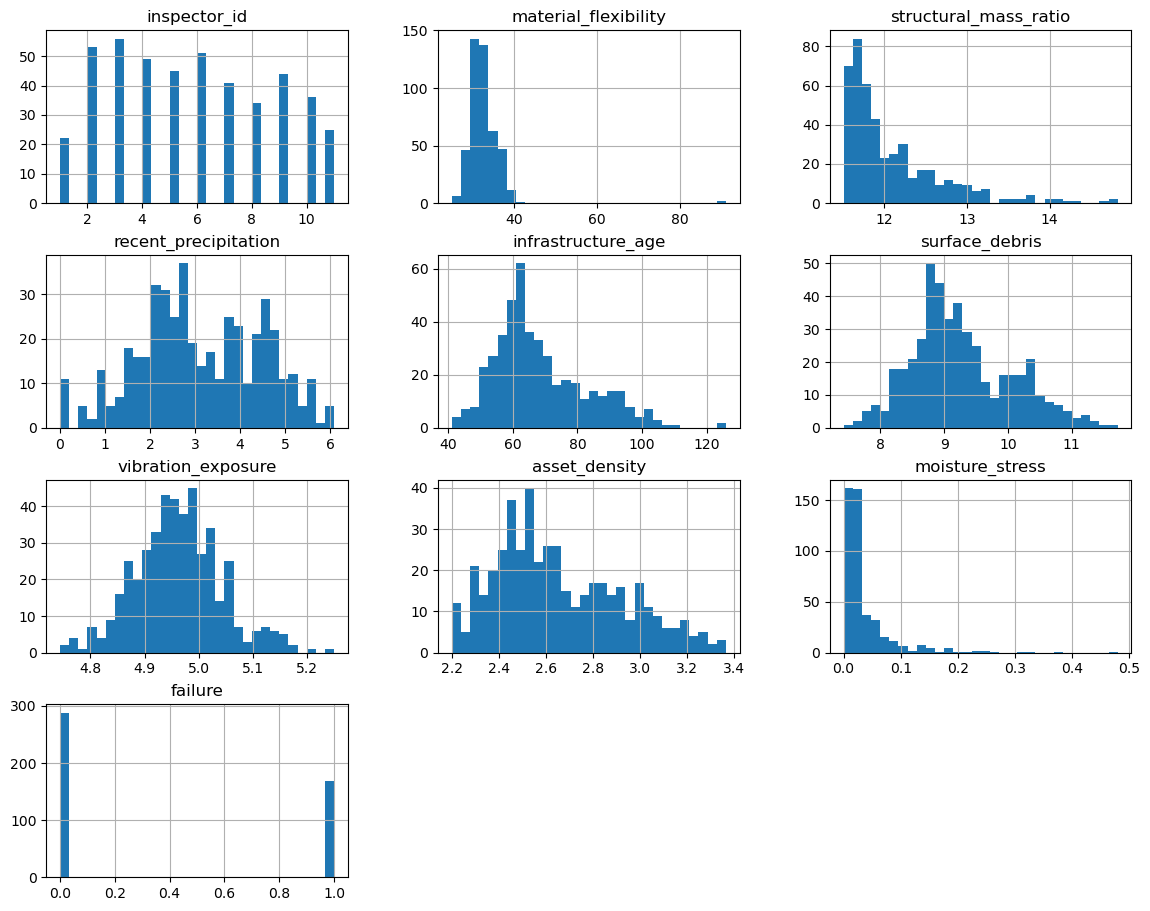

In [9]:
#Looking at distribution of data
#Hist plots of all features to check for outliers and skewness
#Hist highlights outliers in material flexibility

urbandata.hist(bins = 30, figsize = (14,11))
plt.show()

In [24]:
#Checking how many outliers there are in material flexibility, using 45 as a threshold

outliers_1 = urbandata.loc[urbandata["material_flexibility"] > 45]

display(outliers_1)

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
9,2,91.157913,12.004540,2.661193,55.022194,8.960423,4.858190,2.55912,winter,night,0.01,0
421,5,91.157913,12.053391,3.817170,64.528942,9.192685,4.953214,2.68840,winter,afternoon,0.01,0


## 2

Splitting data for training/testing


In [15]:
#define feature and target variables for splitting data into training and testing sets

X = urbandata.drop(columns = ["failure"])
y = urbandata["failure"]

In [16]:
#Splitting data into training and testing sets, using 80% of data for training and 20% for testing, setting random state to 42 for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [17]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((364, 11), (364,), (92, 11), (92,))

## 3

Clean training data

In [23]:
#1. Getting rid of unnecessary columns, such as the insector_id, which is just an identifier and does not provide any useful information for the model

X_train_cleaned = X_train.drop(columns = ["inspector_id"])
y_train_cleaned = y_train.drop(columns = ["inspector_id"])

#2. Reset index

X_train_cleaned = X_train_cleaned.reset_index(drop = True)
y_train_cleaned = y_train_cleaned.reset_index(drop = True)


In [25]:
#Getting rid of outliers in material flexibility, using 45 as a threshold

X_train_cleaned = X_train_cleaned.loc[X_train_cleaned["material_flexibility"] <= 45]
y_train_cleaned = y_train_cleaned.loc[X_train_cleaned["material_flexibility"] <= 45]

In [ ]:
#Dealing with spelling errors

X_train_cleaned["inspection_season"].unique()

array(['summer', 'autumn', 'winter', 'spring', 'sumer'], dtype=object)

In [30]:
X_train_cleaned["inspection_window"].unique()   

array(['afternoon', 'morning', 'night'], dtype=object)

In [31]:
X_train_cleaned["inspection_season"] = X_train_cleaned["inspection_season"].replace({"sumer": "summer"})
X_train_cleaned["inspection_season"].unique()

array(['summer', 'autumn', 'winter', 'spring'], dtype=object)

In [39]:
#Imputing missing values in numerical columns with the median value of each column, as the median is less affected by outliers than the mean

missing_cols = ["structural_mass_ratio", 
                "recent_precipitation",
                "infrastructure_age",
                "vibration_exposure",
                "moisture_stress"]

for col in missing_cols:
    # Calculate the median first
    median_val = X_train_cleaned[col].median()
    # Reassign the column with the filled values
    X_train_cleaned[col] = X_train_cleaned[col].fillna(median_val)


In [40]:
X_train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 0 to 363
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   material_flexibility   364 non-null    float64
 1   structural_mass_ratio  364 non-null    float64
 2   recent_precipitation   364 non-null    float64
 3   infrastructure_age     364 non-null    float64
 4   surface_debris         364 non-null    float64
 5   vibration_exposure     364 non-null    float64
 6   asset_density          364 non-null    float64
 7   inspection_season      364 non-null    object 
 8   inspection_window      364 non-null    object 
 9   moisture_stress        364 non-null    float64
dtypes: float64(8), object(2)
memory usage: 31.3+ KB


## 4

1. Encoding catagorical variables
2. Normalising numerical variables

In [41]:
numerical_features = X_train_cleaned.select_dtypes(include = ["int64", "float64"]).columns
categorical_features = X_train_cleaned.select_dtypes(include = ["object"]).columns

numerical_features, categorical_features

(Index(['material_flexibility', 'structural_mass_ratio', 'recent_precipitation',
        'infrastructure_age', 'surface_debris', 'vibration_exposure',
        'asset_density', 'moisture_stress'],
       dtype='object'),
 Index(['inspection_season', 'inspection_window'], dtype='object'))

In [42]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

# define the data preparation for the columns
#
# categorical columns will have a one hot encoder applied
#   (note - we also set this to drop the first "dummy" column, similer to what we did last week; we have also
#    told it how to handle unknown values, those that don't appear in the training data but do appear in validation
#    or testing. 'infrequent_if_exist' assigns any unknown values to a separate category)
#
# numerical columns will be normalised
#
# each processing step also includes the list of columns that it will be applied to
t = [('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist'), categorical_features), ('num', MinMaxScaler(), numerical_features)]
col_transform = ColumnTransformer(transformers=t)


# fit() works out which columns to make and stores them in "enc"
col_transform.fit(X_train_cleaned)

# transform() then makes those columns in the data set we provide
X_train_encoded = col_transform.transform(X_train_cleaned)

# X_train_encoded will now be a numpy array, which can be used for training
# the columns in this are the raw data
print(X_train_encoded)

[[0.         1.         0.         ... 0.56377772 0.60996564 0.16666667]
 [0.         0.         0.         ... 0.65357934 0.46632302 0.04166667]
 [0.         1.         0.         ... 0.89690903 0.64329897 0.10416667]
 ...
 [1.         0.         0.         ... 0.69973043 0.35979381 0.        ]
 [0.         1.         0.         ... 0.38697274 0.39347079 0.10416667]
 [1.         0.         0.         ... 0.27989755 0.17539519 0.04166667]]


In [43]:
column_names = col_transform.get_feature_names_out()

# 2. Create the DataFrame using the numpy array and the new names
X_train_df = pd.DataFrame(X_train_encoded, columns=column_names)

# 3. View the first few rows
display(X_train_df.head())

,cat__inspection_season_spring,cat__inspection_season_summer,cat__inspection_season_winter,cat__inspection_window_morning,cat__inspection_window_night,num__material_flexibility,num__structural_mass_ratio,num__recent_precipitation,num__infrastructure_age,num__surface_debris,num__vibration_exposure,num__asset_density,num__moisture_stress
0,0.0,1.0,0.0,0.0,0.0,0.595624,0.456047,0.760844,0.347742,0.484617,0.563778,0.609966,0.166667
1,0.0,0.0,0.0,0.0,0.0,0.597861,0.100922,0.562070,0.240755,0.491973,0.653579,0.466323,0.041667
2,0.0,1.0,0.0,1.0,0.0,0.716093,0.383663,0.775640,0.519281,0.680794,0.896909,0.643299,0.104167
3,0.0,0.0,1.0,1.0,0.0,0.428762,0.089018,0.461005,0.192263,0.335650,0.463823,0.347766,0.020833
4,0.0,0.0,0.0,0.0,1.0,0.224179,0.052957,0.301616,0.262158,0.204044,0.486888,0.225430,0.041667


## 5.

Logistic regression model

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize the model
# 'liblinear' is good for small datasets like urbandata.csv
log_reg = LogisticRegression(solver='liblinear', random_state=42)

# Get the average F1-score across 5 folds
scores = cross_val_score(log_reg, X_train_encoded, y_train, cv=5, scoring='f1')
print(f"Average CV F1-Score: {scores.mean():.4f}")

Average CV F1-Score: 0.8764


In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define the parameters you want to test
# C: small values = high regularization, large values = low regularization
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'] # 'l1' is Lasso, 'l2' is Ridge
}

# 2. Initialize the model (using 'liblinear' as it supports both l1 and l2)
log_reg = LogisticRegression(solver='liblinear', random_state=42)

# 3. Set up the Grid Search
# cv=5 means 5-fold cross-validation
# scoring='f1' ensures we optimize for the balance of precision and recall
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', verbose=1)

# 4. Run the search on your training data
grid_search.fit(X_train_encoded, y_train)

# 5. View results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Validation F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 10, 'penalty': 'l2'}
Best Validation F1-Score: 0.8896


In [19]:
#Dropping the outliers in material flexibility, as they are likely to skew the model and there are only 2 of them

training_cleaned = urbandata.drop(count_1.index)

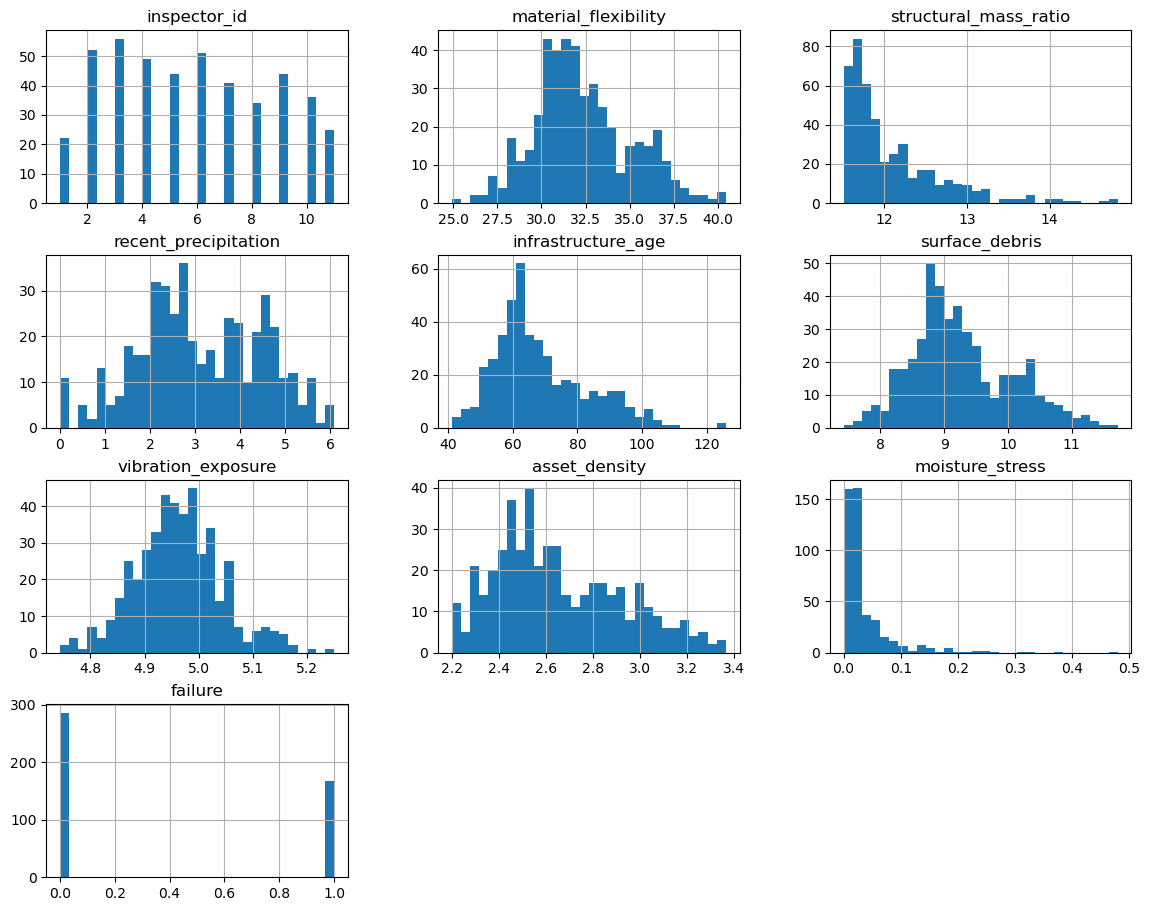

In [20]:

training_cleaned.hist(bins = 30, figsize = (14,11))
plt.show()

In [21]:
#Looking at the info again to see if there are any null values left after dropping the outliers

training_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 454 entries, 0 to 455
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   inspector_id           454 non-null    int64  
 1   material_flexibility   454 non-null    float64
 2   structural_mass_ratio  453 non-null    float64
 3   recent_precipitation   452 non-null    float64
 4   infrastructure_age     450 non-null    float64
 5   surface_debris         454 non-null    float64
 6   vibration_exposure     453 non-null    float64
 7   asset_density          454 non-null    float64
 8   inspection_season      454 non-null    object 
 9   inspection_window      454 non-null    object 
 10  moisture_stress        451 non-null    float64
 11  failure                454 non-null    int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 46.1+ KB


In [ ]:
#Dropping inspector_id as it is a unique identifier and will not be useful for the model

data_cleaned.drop("inspector_id", axis = 1, inplace = True)

In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 454 entries, 0 to 455
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   material_flexibility   454 non-null    float64
 1   structural_mass_ratio  453 non-null    float64
 2   recent_precipitation   452 non-null    float64
 3   infrastructure_age     450 non-null    float64
 4   surface_debris         454 non-null    float64
 5   vibration_exposure     453 non-null    float64
 6   asset_density          454 non-null    float64
 7   inspection_season      454 non-null    object 
 8   inspection_window      454 non-null    object 
 9   moisture_stress        451 non-null    float64
 10  failure                454 non-null    int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 42.6+ KB


In [ ]:
data_cleaned.describe()

,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,moisture_stress,failure
count,454.000000,453.000000,452.000000,450.000000,454.000000,453.000000,454.000000,451.000000,454.000000
mean,32.334037,12.089507,3.110293,68.571407,9.272629,4.962932,2.654746,0.037228,0.370044
std,2.709153,0.592993,1.367810,14.507851,0.791734,0.080134,0.268765,0.051864,0.483349
min,24.924765,11.506094,0.000000,41.087602,7.426926,4.743956,2.200000,0.000000,0.000000
25%,30.492135,11.671100,2.138041,58.613206,8.743250,4.912084,2.450940,0.010000,0.000000
50%,31.897913,11.863909,2.925396,64.859656,9.125281,4.961058,2.595360,0.020000,0.000000
75%,33.879719,12.337689,4.324082,76.743834,9.772912,5.011109,2.845200,0.040000,1.000000
max,40.452981,14.823489,6.089045,125.949552,11.719278,5.249006,3.364000,0.480000,1.000000


In [ ]:
#Defining the columns with missing values and filling them with the median, as they are all numerical features and the median is less likely to be skewed by outliers than the mean

missing_cols = ["structural_mass_ratio", 
                "recent_precipitation",
                "infrastructure_age",
                "vibration_exposure",
                "moisture_stress"]

for col in missing_cols:
    data_cleaned[col].fillna(data_cleaned[col].median(), inplace = True)

C:\Users\Danie\AppData\Local\Temp\ipykernel_8168\728468020.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[col].fillna(data_cleaned[col].median(), inplace = True)


In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 454 entries, 0 to 455
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   material_flexibility   454 non-null    float64
 1   structural_mass_ratio  454 non-null    float64
 2   recent_precipitation   454 non-null    float64
 3   infrastructure_age     454 non-null    float64
 4   surface_debris         454 non-null    float64
 5   vibration_exposure     454 non-null    float64
 6   asset_density          454 non-null    float64
 7   inspection_season      454 non-null    object 
 8   inspection_window      454 non-null    object 
 9   moisture_stress        454 non-null    float64
 10  failure                454 non-null    int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 42.6+ KB


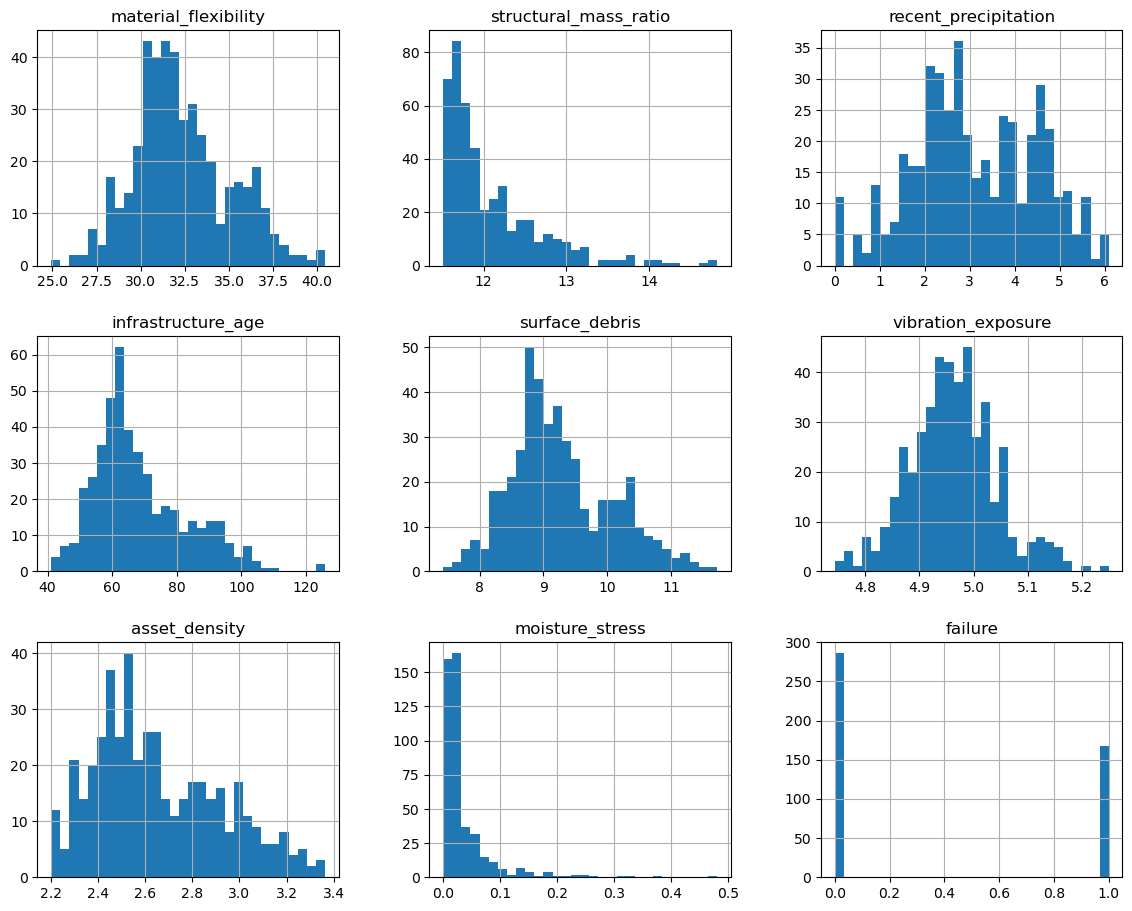

In [ ]:
data_cleaned.hist(bins = 30, figsize = (14,11))
plt.show()